In [2]:
import glob
import matplotlib.pyplot as plt
import os
import numpy as np
import xarray as xr
import pandas as pd
import math
from PIL import Image
from skimage import color
from skimage import io
import cv2

# Load data

In [3]:
file_name = '20220727/pass_216_175719_ffc/frame_c305_20220727_175642_sky_bluesky.png'
dataset = xr.open_dataset('core_faam_20220727_v005_r0_c305_1hz.nc')
cloud_passes = pd.read_csv('FAAM_cloudpass_info.csv')

In [4]:
#file_name = '20220727/pass_216_175719_ffc/frame_c305_20220727_175642_sky_bluesky.png' # ffc 
#file_name = '20220727/pass_211_163638_rfc/frame_c305_20220727_163653_allcloud.png' # rfc 2
#file_name = '20220727/pass_212_164120_rfc/frame_c305_20220727_164133_sky_bluesky.png'# near 3 
#file_name = '20220727/pass_212_164120_rfc/frame_c305_20220727_164141_sky_bluesky.png'# far 4
#file_name = '20220727/pass_211_163625_ffc/frame_c305_20220727_163609_sky_bluesky.png'# near 5
file_name = '20220727/pass_211_163625_ffc/frame_c305_20220727_163545_sky_bluesky.png'# far 6

# Functions to extract air craft data, cloud position and distance camera to cloud

In [5]:
def extract_pass_number(file_name):
    filepath_parts = file_name.split('/')
    pass_number= filepath_parts[1].split('_')[1]
    return pass_number

In [6]:
def extract_timestamp_from_filename(filepath):
    filepath_parts = filepath.split('/')
    filename_parts = filepath_parts[2].split('_')
    camera= filepath_parts[1].split('_')[3]
    date = filename_parts[2]
    times = filename_parts[3]
    full_timestamp = pd.to_datetime(date+'_'+times, format="%Y%m%d_%H%M%S")
    return [camera, full_timestamp] 

In [7]:
# Define a function to find the closest roll_time and get the corresponding roll_angle
def get_closest_roll_angle(aircraft_df, frame_time):
    # Calculate the absolute difference between frame_time and all roll_times
    diffs = abs(aircraft_df['times'] - frame_time)
    # Find the index of the minimum difference
    min_diff_index = diffs.idxmin()
    # Return the corresponding roll_angle
    return aircraft_df.loc[min_diff_index]

In [8]:
def extract_variables(dataset):
    roll = dataset['ROLL_GIN']
    lat = dataset['LAT_GIN'].data[:]
    lon = dataset['LON_GIN'].data[:]
    pitch = dataset['PTCH_GIN'].data[:]
    alt = dataset['ALT_GIN'].data[:]
    roll_times = roll.Time
    roll_angle = roll.data[:]
    roll_times_pd = pd.to_datetime(roll_times.data)
    aircraft_df = pd.DataFrame({'times': roll_times_pd, 'lat': lat, 'lon' : lon, 'pitch' : pitch, 'alt': alt, 'roll_angles': roll_angle})
    return aircraft_df


In [9]:
def extract_cloud_pass_info(cloud_passes, camera, pass_number):
    pass_info = cloud_passes.loc[int(pass_number)-1]
    if camera=='ffc':
        cloud_lat = pass_info['start_lat']
        cloud_lon = pass_info['start_lon']
        cloud_height = pass_info['alt']
    else:
        cloud_lat = pass_info['end_lat']
        cloud_lon = pass_info['end_lon']
        cloud_height = pass_info['alt']
    return [cloud_lat, cloud_lon, cloud_height]

In [10]:
def haversine( lon1, lat1, lon2, lat2, alt):
    R = 6371e3 + alt # radius of Earth in metres
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    dphi = phi2-phi1
    
    lambda1 = math.radians(lon1)
    lambda2 = math.radians(lon2)
    dlambda = lambda2-lambda1

    a = math.sin(dphi/2) * math.sin(dphi/2) + math.cos(phi1) * math.cos(phi1) * math.sin(dlambda/2) * math.sin(dlambda/2)
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

    d = R * c
    
    return d

In [11]:
# Get the distance
camera, timestamp = extract_timestamp_from_filename(file_name)
pass_number = extract_pass_number(file_name)
aircraft_df = extract_variables(dataset)
aircraft_position = get_closest_roll_angle(aircraft_df, timestamp)
pass_info = extract_cloud_pass_info(cloud_passes, camera, pass_number)

In [12]:
D = haversine(aircraft_position['lon'], aircraft_position['lat'], pass_info[1], pass_info[0], pass_info[2])

In [13]:
print('Distance to cloud: ', D)

Distance to cloud:  6101.044036857376


# find pixel height

In [14]:
# Set Constants for edge detection:
# How white vs grey (this might need to be set by trial and error)    
WHITENESS_THRESHOLD = 110
# line thickness of box
THICKNESS = 10
# The part of every photo is just ground set to 0 if whole photo is cloud
NOTSKY = 450

In [15]:


img = io.imread(file_name)
img_grey = color.rgb2gray(img)

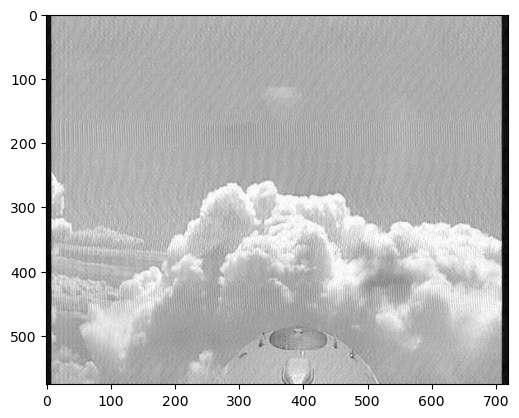

In [16]:
plt.imshow(img_grey,cmap='gray')  
 

In [17]:
img_grey = cv2.bilateralFilter(img, 9, 75, 75)
cv_grey = cv2.GaussianBlur(img_grey.astype(np.uint8) * 255, (5, 5), 0)
  

In [18]:
# More aggressive filtering required here!

In [19]:
# Needed more aggressive filtering
img_grey = cv2.bilateralFilter(img, 18, 100, 100)
cv_grey = cv2.GaussianBlur(img_grey.astype(np.uint8) * 255, (5, 5), 0)
edges = cv2.Canny(cv_grey, 0, 200)
edges[NOTSKY::,:]=0
edges[:,0:20]=0
edges[:,-15::]=0

# Find contours and sort by area
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, 
                                   cv2.CHAIN_APPROX_SIMPLE)

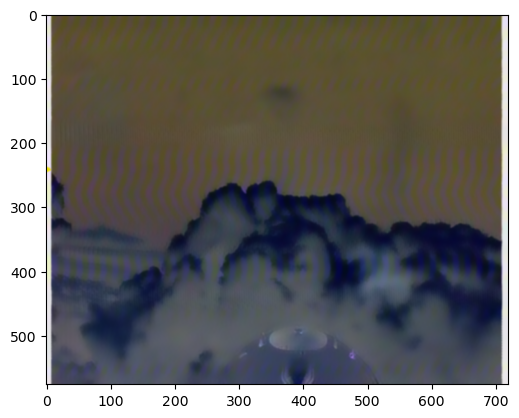

In [20]:

plt.imshow(cv_grey)

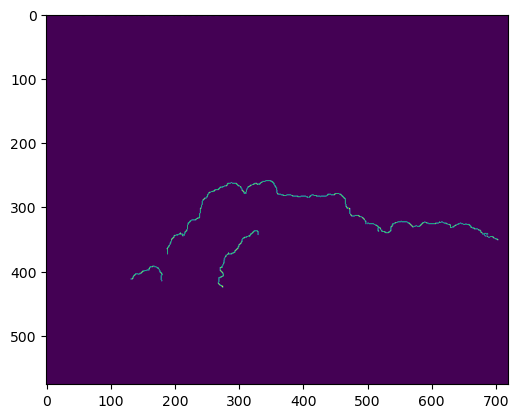

In [21]:

plt.imshow(edges)

In [22]:
# Draw the contours on the original image
thickness = 8  # Adjust this value to control the thickness of the drawn contours
edge_image = cv2.imread(file_name).copy()
cv2.drawContours(edge_image, contours, -1, (0, 255, 0), thickness)

array([[[40, 21, 29],
        [38, 19, 27],
        [50, 28, 37],
        ...,
        [ 0, 36, 13],
        [ 0, 34, 23],
        [ 0, 31, 20]],

       [[39, 20, 28],
        [36, 17, 25],
        [46, 24, 33],
        ...,
        [ 0, 37, 14],
        [ 0, 36, 25],
        [ 0, 36, 25]],

       [[ 5, 29, 26],
        [ 3, 27, 24],
        [12, 29, 25],
        ...,
        [ 0, 40, 28],
        [ 0, 40, 23],
        [ 0, 41, 24]],

       ...,

       [[10, 24,  9],
        [11, 25, 10],
        [20, 34, 19],
        ...,
        [ 5, 38, 28],
        [ 0, 26, 13],
        [ 0, 25, 12]],

       [[ 0, 25,  4],
        [ 0, 32, 11],
        [13, 41, 24],
        ...,
        [ 0, 28, 19],
        [ 0, 28, 18],
        [ 0, 24, 14]],

       [[ 0, 28,  7],
        [ 0, 29,  8],
        [11, 39, 22],
        ...,
        [ 0, 27, 18],
        [ 0, 26, 16],
        [ 0, 23, 13]]], dtype=uint8)

In [23]:
cv2.imwrite('cloud_edge.png', edge_image)

True

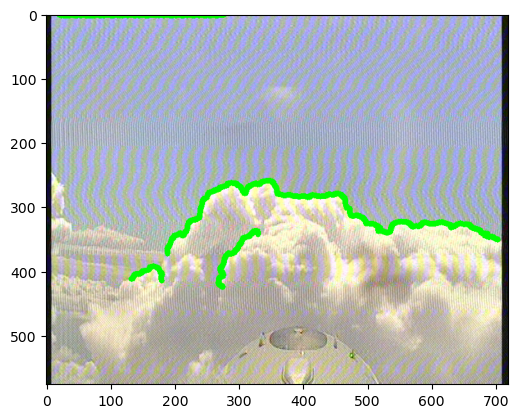

In [24]:
cloud_edge=Image.open('cloud_edge.png')
plt.imshow(cloud_edge)

In [25]:
sorted_contours = sorted(contours, key=cv2.contourArea, reverse=True)
bounding_box_image = cv2.imread(file_name).copy()
max =0 
for contour in sorted_contours:
    (x, y, w, h) = cv2.boundingRect(contour)
    rectanglea = w*h
    print(rectanglea,max)
    if rectanglea >= max:
        x_max = x
        y_max = y
        w_max = w
        h_max = h
        max=rectanglea

25415 0
4536 25415
5607 25415
1200 25415
1464 25415
675 25415
126 25415
774 25415


In [26]:
cv2.rectangle(bounding_box_image, (x_max, y_max), (x_max + w_max, y_max + h_max), (0, 255, 0), thickness)

array([[[40, 21, 29],
        [38, 19, 27],
        [50, 28, 37],
        ...,
        [ 0, 36, 13],
        [ 0, 34, 23],
        [ 0, 31, 20]],

       [[39, 20, 28],
        [36, 17, 25],
        [46, 24, 33],
        ...,
        [ 0, 37, 14],
        [ 0, 36, 25],
        [ 0, 36, 25]],

       [[ 5, 29, 26],
        [ 3, 27, 24],
        [12, 29, 25],
        ...,
        [ 0, 40, 28],
        [ 0, 40, 23],
        [ 0, 41, 24]],

       ...,

       [[10, 24,  9],
        [11, 25, 10],
        [20, 34, 19],
        ...,
        [ 5, 38, 28],
        [ 0, 26, 13],
        [ 0, 25, 12]],

       [[ 0, 25,  4],
        [ 0, 32, 11],
        [13, 41, 24],
        ...,
        [ 0, 28, 19],
        [ 0, 28, 18],
        [ 0, 24, 14]],

       [[ 0, 28,  7],
        [ 0, 29,  8],
        [11, 39, 22],
        ...,
        [ 0, 27, 18],
        [ 0, 26, 16],
        [ 0, 23, 13]]], dtype=uint8)

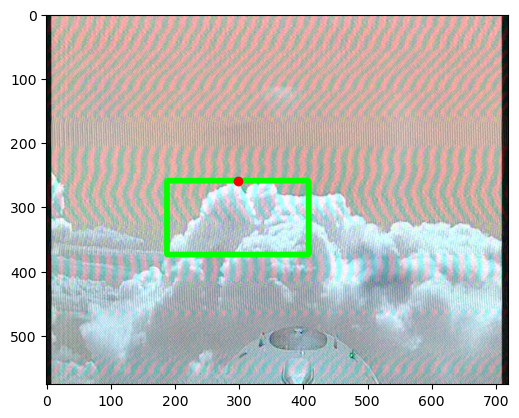

In [27]:
plt.imshow(bounding_box_image)
x_mw = (x_max + w_max/2)
plt.plot(x_mw, y_max, 'ro')


In [28]:
pixel_height = 576- y_max

# find cloud height

In [29]:
focal_length_mm = 50         # Focal Length in mm
sensor_height_mm = 24        # Sensor height in mm
sensor_width_mm = 35.9       # Sensor width in mm
focal_length_mm = 50.0       # Focal length in mm
FOV = 0         # Field of View (to be calculated later)

In [30]:
# Calculating FOV angles in degrees

# Calculate FOV angles in radians
fov_horizontal_rad = 2 * math.atan(sensor_width_mm / (2 * focal_length_mm))
fov_vertical_rad = 2 * math.atan(sensor_height_mm / (2 * focal_length_mm))

# Convert FOV angles to degrees
fov_horizontal_deg = math.degrees(fov_horizontal_rad)
fov_vertical_deg = math.degrees(fov_vertical_rad)
FOV = fov_vertical_deg

# Displaying FOV angles
print("FOV Horizontal Angle:", fov_horizontal_deg, "degrees")
print("FOV Vertical Angle:", fov_vertical_deg, "degrees")

FOV Horizontal Angle: 39.496276026438636 degrees
FOV Vertical Angle: 26.991466561591622 degrees


In [39]:
# Function to find height of an object given its pixel position on the sensor


def find_height(P, Distance, focal_length_mm, sensor_height_mm):
    """
    Calculate the height of an object given its pixel position on the sensor.

    Parameters:
    - P: Pixel position of the object on the sensor
    - Distance: Distance to the object in millimeters
    - focal_length_mm: Focal length of the camera lens in millimeters
    - sensor_height_mm: Height of the camera sensor in millimeters

    Returns:
    - Height of the object in kilometers (rounded to 2 decimal places)
    """
    OHS = find_OHS(P, sensor_height_mm)
    H = (Distance * 10**3 * OHS) / focal_length_mm
    return round(H / 10**3, 2)

# Object height on sensor =  (Sensor height (mm) × Object height (pixels))
#                                      / Sensor height (pixels)
# Sensor height (px) = Sensor height (mm) / distance between pixels
# sensor_height_pixels = 24*10**-3 / 5.73*10**-6
# sensor_height_pixels = 4188

# Function to calculate Object Height on Sensor


def find_OHS(P, sensor_height_mm):
    """
    Calculate the Object Height on Sensor.

    Parameters:
    - P: Pixel position of the object on the sensor
    - sensor_height_mm: Height of the camera sensor in millimeters

    Returns:
    - Object Height on Sensor
    """
    sensor_height_pixels = 4188
    OHS = sensor_height_mm * P / sensor_height_pixels
    return OHS


def pitch_correct(P, FieldOfView, h):
    """
    Correct the pitch of the camera based on angles and height.

    Parameters:
    - P: pitch in degrees
    - FieldOfView: Field of View of the camera in degrees
    - h: Height on the inclined plane

    Returns:
    - True height after pitch correction
    """
    # See diagram for agles a, b and c
    a = 90 - P - FieldOfView/2
    b = 180 - 90 - FieldOfView/2
    # image plane incline from vertical
    c = 180 - a - b
    # x is true height, h is height on incled place
    x = h * math.cos(c)
    return x

In [40]:
CTH_raw= find_height(pixel_height, D, focal_length_mm, sensor_height_mm)
CTH_rel_to_plane = pitch_correct(aircraft_position['pitch'], FOV, CTH_raw)


In [41]:
cloud_top_height = CTH_rel_to_plane + aircraft_position['alt']

In [42]:
CTH_rel_to_plane

-113.90316861708003

In [43]:
print('the estimated cloud top height is: ', cloud_top_height)

the estimated cloud top height is:  6986.88149935167


In [44]:
print('the pass height was: ', pass_info[2])

the pass height was:  5161.6514


In [45]:
aircraft_position

times          2022-07-27 16:35:45
lat                      33.985691
lon                    -107.336288
pitch                     6.534913
alt                    7100.784668
roll_angles              -3.867579
Name: 10768, dtype: object

In [38]:
cloud_passes.iloc[210]

Unnamed: 0                            210
flight_id                            c305
start_index                         10808
start_datetime        2022-07-27 16:36:25
end_index                           10821
end_datetime          2022-07-27 16:36:38
npasses                               1.0
passes_start_index                [10808]
passes_end_index                  [10821]
start_lon                      -107.27162
start_lat                       33.974274
end_lon                        -107.25048
end_lat                         33.969543
alt_pre                          7139.763
pressalt_pre                     6705.189
press_pre                        427.9394
alt                             5161.6514
pressalt                         4852.616
press                           564.68585
alt_post                        7133.0103
pressalt_post                   6700.1104
press_post                      428.34952
nondT_pre                       259.46823
deicedT_pre                     25